# Problem Setup

## Solar PV prediction as a mini-project

This notebook starts the solar PV mini-project. We will define the prediction task, inspect the operating conditions, inspect the normalized power target, and agree on what would count as an acceptable solution.

The goal is shared problem understanding. We are not choosing a model yet; we are making the project concrete enough that the next notebook can make a defensible first modelling choice.


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import importlib
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

REPO_URL = "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git"
REPO_BRANCH = "workshop3"
PACKAGE_NAME = "nextgen2026_mlai_workshops"

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                REPO_BRANCH,
                REPO_URL,
                str(repo_dir),
            ],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    missing_packages = [
        package_name
        for package_name, module_name in (("pandas", "pandas"), ("torch", "torch"))
        if importlib.util.find_spec(module_name) is None
    ]
    if missing_packages:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing_packages], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    repo_dir = None
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / PACKAGE_NAME).exists():
            repo_dir = possible_root
            sys.path.insert(0, str(possible_src))
            break

for module_name in list(sys.modules):
    if module_name == PACKAGE_NAME or module_name.startswith(f"{PACKAGE_NAME}."):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import numpy as np

workshop_pkg = importlib.import_module(PACKAGE_NAME)
from nextgen2026_mlai_workshops import solar_pv as _pv_check

package_version = getattr(workshop_pkg, "__version__", "unknown")
print(
    f"Workshop 3 environment ready. Package: {PACKAGE_NAME} {package_version}. "
    f"Repository: {repo_dir or 'installed environment'}"
)


Matplotlib is building the font cache; this may take a moment.


Workshop 3 environment ready. Package: nextgen2026_mlai_workshops 0.1.0. Repository: /Users/samuelklettnavarro/Dropbox/UNI/Z.Admin/CSIRO/CODING_BOOTCAMP/standalone-mlai-workshops


<br>

## Learning Outcomes

By the end of this notebook, you should be able to:

1. state the solar PV prediction task in input-output form;
2. identify the input variables and the target variable;
3. describe common and rare ranges in the dataset;
4. interpret simple target summaries and target-by-input slices;
5. explain the project success criterion in input terms.

The central question is:

> What problem are we asking the model to solve, and what would count as good enough?


<br>

## Setup

This cell imports the solar PV helper module and creates the project dataset for this notebook. The table we inspect contains three operating-condition inputs and one normalized power target.

The setup output should answer a basic readiness question: how many observations are available, which columns are inputs, and which column is the prediction target.


In [2]:
# Load helpers and assemble the dataset used for problem setup.
from nextgen2026_mlai_workshops import solar_pv as pv
import matplotlib.pyplot as plt
import numpy as np

project_bundle = pv.make_workshop3_bundle("baseline", seed=7)
data_parts = [
    data for data in project_bundle.values()
    if isinstance(data, dict) and project_bundle["target"] in data
]
project_data = pv.concat_data(data_parts, name="project data")
input_columns = ["irradiance", "ambient_temperature", "tilt_angle"]
target_column = project_bundle["target"]
criterion = project_bundle["criterion"]

print(f"Loaded {len(project_data[target_column])} project observations.")
print(f"Inputs: {', '.join(input_columns)}")
print(f"Target: {target_column}")


Loaded 1000 project observations.
Inputs: irradiance, ambient_temperature, tilt_angle
Target: normalized_power


<br>

## 1. Formalize The Task

A model is useful only relative to a task. Here the task is to learn a function from operating conditions to normalized PV power.

Let $P$ denote normalized power. Let $I$ be irradiance, $T_a$ be ambient temperature, and $\alpha$ be tilt angle. The input and target are:

$$
x=(I,T_a,\alpha)\in X \subset\mathbb{R}^3,
\qquad
P\in[0,1].
$$

The observed dataset is:

$$
\mathcal{D}=\{(x_i,P_i)\}_{i=1}^{n}.
$$

The prediction rule we want is:

$$
h_\theta: X \to [0,1],
\qquad
\widehat{P}=h_\theta(x)\approx P.
$$

Normalized power is scaled to be roughly interpretable on a 0-to-1 range. A useful prediction could support monitoring or planning when operating conditions are known and expected output needs to be estimated.

**Discussion:** What would make this prediction useful in a real PV monitoring or planning setting?

**Takeaway:** The project is a supervised regression task from operating conditions to normalized PV power.


<br>

## 2. Explore The Inputs

Before fitting any model, inspect what values the learner receives. The schema and histograms below show the measurement units, expected ranges, and marginal distribution of each input.

Look for common values, rare values, and observations near the boundaries of the stated ranges.

**Discussion:** Which input ranges are common? Which ranges look rare? What can these one-variable plots not show?


| Input               | Unit    | Expected range | Min    | Median   | Max       |
| :------------------ | :------ | :------------- | -----: | -------: | --------: |
| irradiance          | W/m2    | 0-1000         | 0.0000 | 602.1001 | 1000.0000 |
| ambient_temperature | C       | 5-45           | 6.4375 |  26.2707 |   45.0000 |
| tilt_angle          | degrees | 0-60           | 0.0000 |  29.4782 |   56.8942 |


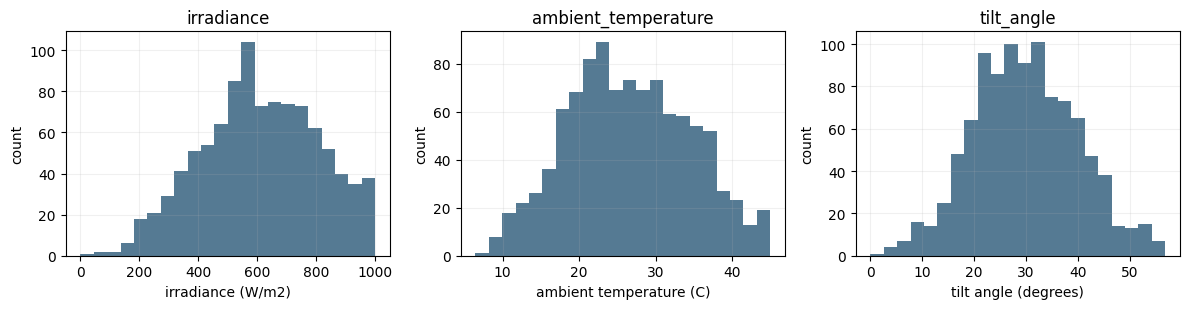

In [3]:
# Print the schema summary and plot input histograms.
pv.print_table(
    ["Input", "Unit", "Expected range", "Min", "Median", "Max"],
    pv.describe_inputs(project_data),
)

labels = {
    "irradiance": "irradiance (W/m2)",
    "ambient_temperature": "ambient temperature (C)",
    "tilt_angle": "tilt angle (degrees)",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, input_columns):
    ax.hist(project_data[col], bins=22, color="#2F5D7C", alpha=0.82)
    ax.set_title(col)
    ax.set_xlabel(labels[col])
    ax.set_ylabel("count")
    ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()


### AI Analysis

**Conceptual Takeaway:** Marginal distributions provide a "sanity check" for the data range but are insufficient for understanding the feature interactions that drive the target variable.

**Significance:** Identifying "rare" ranges (like very low tilt angles or high temperatures) helps flag where the model might be less certain. It ensures the dataset covers the intended operating envelope.

**Real-world Implications:** In a deployment setting, if a sensor reports values outside these ranges (e.g., 60°C temperature), it triggers an "out-of-distribution" alert, indicating the model's predictions should not be trusted.

**Takeaway:** Marginal summaries show first-order coverage. They do not show whether important combinations of inputs are common, rare, or associated with different target values.


<br>

## 3. Inspect Representative Rows

Aggregate plots are useful, but concrete rows make the observation unit easier to reason about. The next cell shows examples from the low-output, typical-output, and high-output parts of the dataset.

**Discussion:** What differs across low-output and high-output examples? Which differences are obvious from a single row, and which require a broader summary?


### AI Analysis

**Conceptual Takeaway:** Inspecting individual data points (unit level) bridges the gap between abstract distributions and the physical reality of the PV system.

**Significance:** High-output examples typically align with high irradiance, but temperature and tilt also play significant roles. These examples help verify that the data labels "make sense" physically.

**Real-world Implications:** For troubleshooting, a technician might compare a real-time observation against these "representative rows" to quickly determine if the system is underperforming under similar conditions.

In [ ]:
# Select representative rows across low, typical, and high target values.
example_labels = [
    "low output 1",
    "low output 2",
    "typical output 1",
    "typical output 2",
    "high output 1",
    "high output 2",
]
rows = []
for label, row in zip(example_labels, pv.representative_rows(project_data, k=2)):
    rows.append([label, *[row[col] for col in input_columns], row[target_column]])

pv.print_table(["Example", *input_columns, target_column], rows)


**Takeaway:** Individual rows make the prediction target tangible, but they are illustrative rather than representative. Use them alongside distributional summaries.


### AI Analysis

**Conceptual Takeaway:** The target variable (Normalized Power) has a non-uniform distribution, likely skewed by diurnal cycles and weather variations.

**Significance:** A model that simply predicts the "mean" or "median" might have low average error but fail catastrophically during peak production hours. We must ensure the model captures the full range of production levels.

**Real-world Implications:** Grid operators care most about high-power periods (for stability) and low-power periods (for backup planning). A model's failure in the "tails" of this distribution is more costly than in the middle.

<br>

## 4. Explore The Target

The target distribution tells us what values the model must predict. If most observations sit in one part of the target range, a single average error can be harder to interpret.

Inspect the histogram and summary values before relating the target back to the inputs.

**Discussion:** Which parts of the normalized-power range would matter most for this project?


In [ ]:
# Plot the target distribution and print simple summary statistics.
P = project_data[target_column]

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.hist(P, bins=26, color="#7B5E9E", alpha=0.82)
ax.set_title("Distribution of normalized PV power")
ax.set_xlabel("normalized power")
ax.set_ylabel("count")
ax.grid(alpha=0.18)
plt.show()

pv.print_table(
    ["Statistic", "Value"],
    [
        ["min", float(np.min(P))],
        ["10th percentile", float(np.quantile(P, 0.10))],
        ["median", float(np.median(P))],
        ["mean", float(np.mean(P))],
        ["90th percentile", float(np.quantile(P, 0.10))],
        ["max", float(np.max(P))],
    ],
)


### AI Analysis

**Conceptual Takeaway:** Binned means reveal the primary drivers of performance (e.g., strong positive correlation with irradiance) and potential non-linearities (e.g., efficiency drop at high temperatures).

**Significance:** Large standard deviations in a bin suggest that the chosen input doesn't tell the whole story for those observations—other variables are creating the spread.

**Real-world Implications:** If the relationship with temperature is strongly non-linear, a simple linear model will consistently under-predict or over-predict at extreme temperatures, leading to poor seasonal performance.

**Takeaway:** The target summary shows the output range the model must cover. It does not explain which conditions are associated with each output level.


<br>

## 5. Relate The Target To Each Input

A useful model needs to learn how normalized power changes with each input. The next cell bins each input, then summarizes the mean and spread of the target inside each bin.

These are one-dimensional slices. They help us build intuition about function shape, but each slice averages over the other inputs.

**Discussion:** Where does the target change quickly? Where does it change slowly? Does each relationship look linear, curved, variable, or hard to summarize from one input alone?


### AI Analysis

**Conceptual Takeaway:** Joint distributions visualize interactions that 1D plots miss, such as how "optimal tilt" changes depending on the time of day or solar intensity.

**Significance:** The color gradients (power) across two-dimensional input spaces help us identify "clusters of high performance."

**Real-world Implications:** Design engineers use these joint views to optimize panel installation angles for specific geographic climates where certain temperature/irradiance combinations are most common.

In [ ]:
# Summarize target behaviour across one input at a time.
def binned_means(data, column, bins=6):
    x = np.asarray(data[column], dtype=float)
    y = np.asarray(data[target_column], dtype=float)
    edges = np.linspace(float(np.min(x)), float(np.max(x)), bins + 1)
    centers, means, spreads, counts = [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        mask = (x >= left) & ((x < right) if right < edges[-1] else (x <= right))
        centers.append((left + right) / 2)
        counts.append(int(np.sum(mask)))
        means.append(float(np.mean(y[mask])) if np.any(mask) else np.nan)
        spreads.append(float(np.std(y[mask])) if np.any(mask) else np.nan)
    return np.asarray(centers), np.asarray(means), np.asarray(spreads), counts

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col in zip(axes, input_columns):
    centers, means, spreads, counts = binned_means(project_data, col, bins=6)
    ax.errorbar(centers, means, yerr=spreads, fmt="o-", capsize=3, color="#C7502A")
    ax.set_title(f"Target by {col}")
    ax.set_xlabel(labels[col])
    ax.set_ylabel("mean normalized power")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()

for col in input_columns:
    print(f"\nTarget summary by {col}")
    pv.print_table([f"{col} bin", "n", "mean target", "target std"], pv.binned_target_summary(project_data, col, bins=6))


**Takeaway:** Slices are useful for seeing broad target behaviour, but they can blur patterns because the other inputs are changing at the same time.


### AI Analysis

**Conceptual Takeaway:** Performance is not uniform; we care more about accuracy in specific "critical regions" than about the global average.

**Significance:** The "Key Operating Range" represents the system's peak performance envelope. A model that is 99% accurate at night (zero power) but 50% accurate at noon is practically useless.

**Real-world Implications:** In financial modeling for solar farms, the ROI is calculated on peak production. Acceptance tests must prioritize high-irradiance accuracy to ensure the business case holds.

<br>

## 6. Inspect Simple Joint Behaviour

With three inputs, no single plot can show the whole problem. Pairwise views are still useful because they show how target values vary across combinations of conditions.

The next cell shows two pairwise views coloured by normalized power. Use them to compare what one-dimensional summaries show with what pairwise summaries add.

**Discussion:** What do these joint views show that the previous slices did not? What still remains hard to see?


In [ ]:
# Plot pairwise input views coloured by normalized power.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

scatter = axes[0].scatter(
    project_data["irradiance"],
    project_data["ambient_temperature"],
    c=project_data[target_column],
    s=24,
    cmap="viridis",
    alpha=0.72,
    edgecolor="none",
)
axes[0].set_xlabel("irradiance (W/m2)")
axes[0].set_ylabel("ambient temperature (C)")
axes[0].set_title("Power across irradiance and temperature")
axes[0].grid(alpha=0.18)
fig.colorbar(scatter, ax=axes[0], label="normalized power")

scatter = axes[1].scatter(
    project_data["irradiance"],
    project_data["tilt_angle"],
    c=project_data[target_column],
    s=24,
    cmap="viridis",
    alpha=0.72,
    edgecolor="none",
)
axes[1].set_xlabel("irradiance (W/m2)")
axes[1].set_ylabel("tilt angle (degrees)")
axes[1].set_title("Power across irradiance and tilt")
axes[1].grid(alpha=0.18)
fig.colorbar(scatter, ax=axes[1], label="normalized power")

fig.tight_layout()
plt.show()


**Takeaway:** Multi-input behaviour is harder to inspect directly. We need a concrete evaluation criterion, not just reassuring plots.


<br>

## 7. Define The Success Criterion

The mini-project needs a concrete acceptance rule. We will use RMSE because the target is continuous and prediction errors are measured on the normalized-power scale.

An acceptable solution must perform well overall and in a project-relevant operating range:

$$
X_{\mathrm{key}}
=
\left\{(I,T_a,\alpha):
I\geq 700\,\mathrm{W}/\mathrm{m}^2,
\quad
T_a\geq 30^{\circ}\mathrm{C},
\quad
15^{\circ}\leq\alpha\leq45^{\circ}
\right\}.
$$

This range is defined by input values and reflects high-irradiance, high-temperature operation with a key tilt band for PV production.

**Discussion:** Would one overall RMSE be enough for this project? Which errors would be most costly in the key operating range?


In [ ]:
# Display the key operating range and the acceptance thresholds.
key_mask = pv.key_range_mask(project_data, criterion)
key_range_description = (
    f"irradiance >= {criterion.key_irradiance_min:.0f} W/m2; "
    f"ambient_temperature >= {criterion.key_ambient_min:.0f} C; "
    f"{criterion.key_tilt_min:.0f} <= tilt_angle <= {criterion.key_tilt_max:.0f} degrees"
)

pv.print_table(
    ["Project check", "Acceptable if", "Scope definition", "Example count in this dataset"],
    [
        [
            "Overall RMSE",
            f"RMSE <= {criterion.overall_rmse:.3f}",
            "all examples using inputs",
            len(project_data[target_column]),
        ],
        [
            "Key operating-range RMSE",
            f"RMSE <= {criterion.key_range_rmse:.3f}",
            key_range_description,
            int(np.sum(key_mask)),
        ],
    ],
)


**Takeaway:** A model can look reasonable on average and still miss the project claim. The next notebook will choose a first modelling approach and check it against this criterion.


<br>

## 8. Handoff

We now have the task, the dataset, and the acceptance criterion:

$$
h_\theta: X \to [0,1],
\qquad
x\mapsto \widehat{P}=h_\theta(x).
$$

The next notebook chooses a first model for this function and measures whether that first attempt is good enough for the project claim.
